Machine Learning Part 1


In [2]:
import numpy as np
import  pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns
from pyexpat import features

from scipy.stats import pearsonr, alpha

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.shape

(1338, 7)

In [8]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [11]:
numerice_col=['age','bmi','charges']

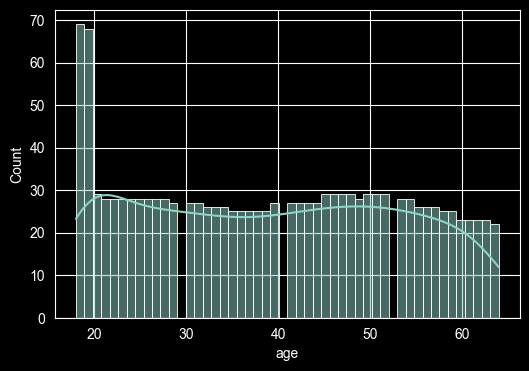

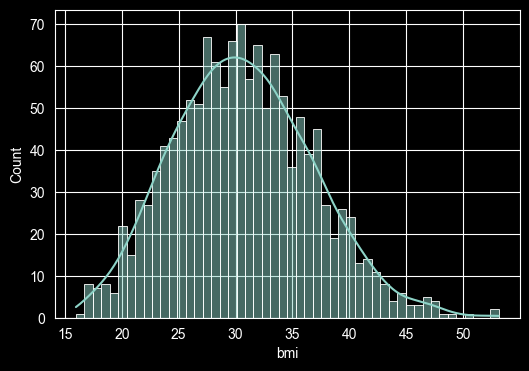

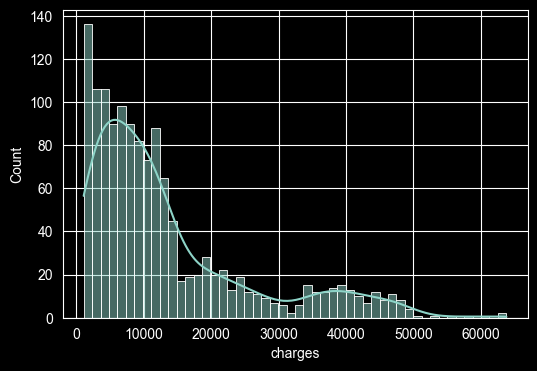

In [12]:
for col in numerice_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=50)

<Axes: xlabel='children', ylabel='count'>

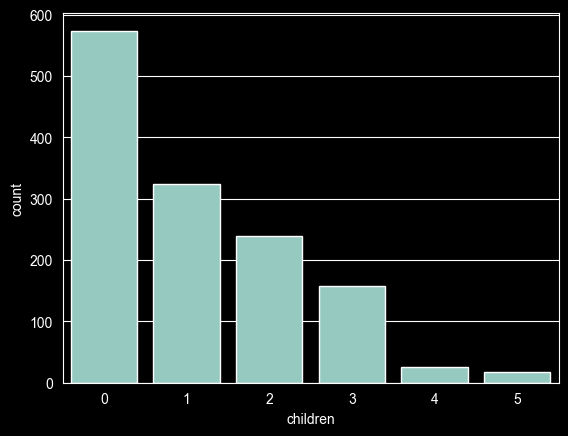

In [13]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

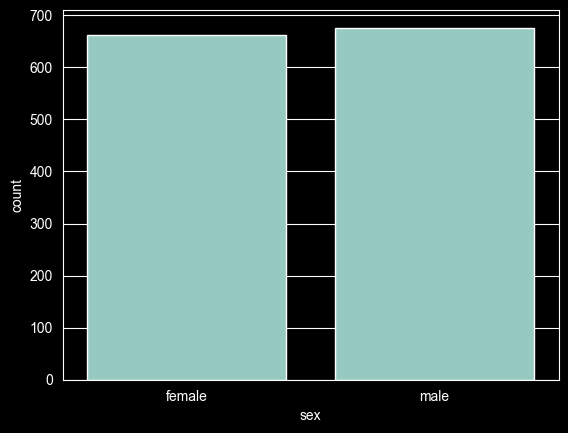

In [14]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

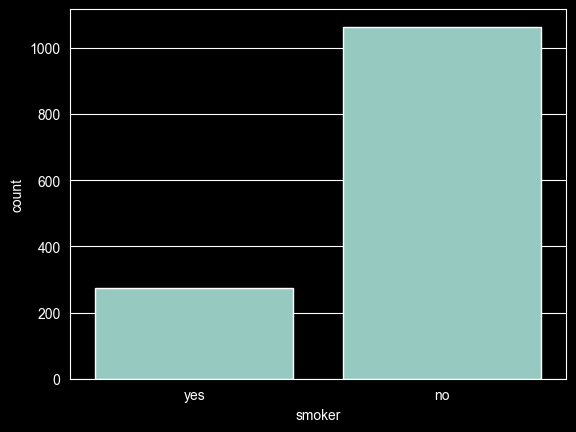

In [15]:
sns.countplot(x=df['smoker'])
# sns.countplot(x=df['region'])

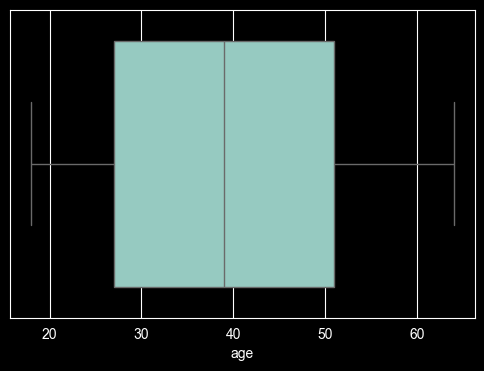

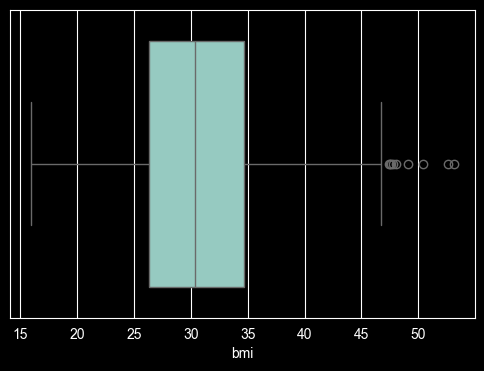

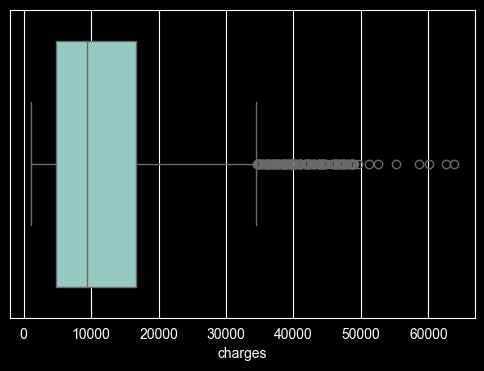

In [16]:
for col in numerice_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: xlabel='children', ylabel='count'>

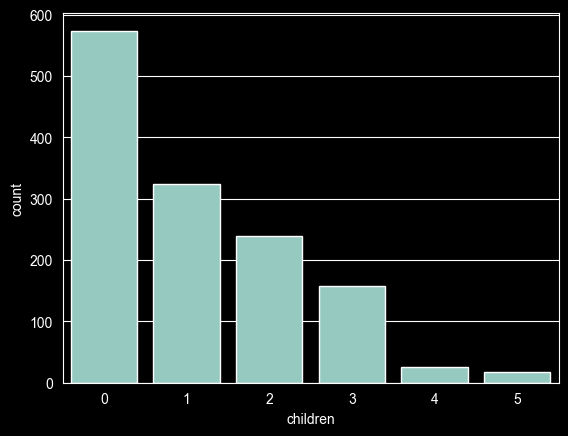

In [18]:
sns.countplot(x=df['children'])
# sns.countplot(x=df['smoker'])

<Axes: >

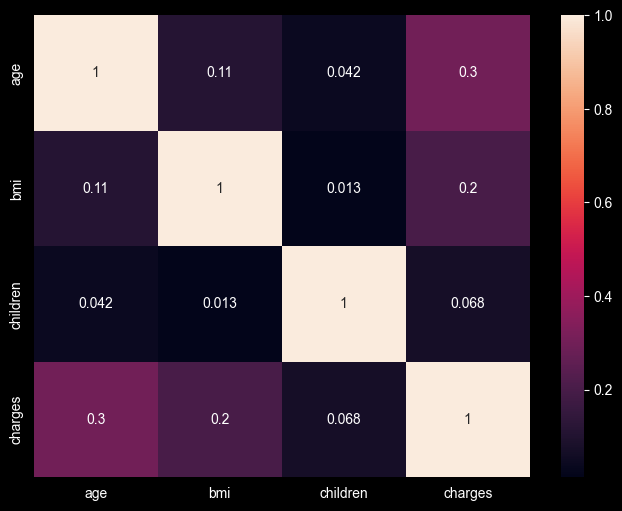

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

#Data Cleaning and processing

In [20]:
df_clean=df.copy()

In [21]:
df_clean.shape

(1338, 7)

In [22]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df_clean.drop_duplicates(inplace=True)

In [24]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [25]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [27]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [28]:
df_clean['sex']=df_clean['sex'].map({'male':0,'female':1})

In [29]:
df_clean.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [30]:
df_clean['smoker'].value_counts()


smoker
no     1063
yes     274
Name: count, dtype: int64

In [31]:
df_clean['smoker']=df_clean['smoker'].map({'no':0,'yes':1})

In [32]:
df_clean.dtypes
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [33]:
 df_clean.describe()

,age,sex,bmi,children,smoker,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,0.495138,30.663452,1.095737,0.204936,13279.121487
std,14.044333,0.500163,6.100468,1.205571,0.403806,12110.359656
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.290000,0.000000,0.000000,4746.344000
50%,39.000000,0.000000,30.400000,1.000000,0.000000,9386.161300
75%,51.000000,1.000000,34.700000,2.000000,0.000000,16657.717450
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [34]:
df_clean.rename(columns={
    'sex':'is_female'
    ,'smoker':'is_smoker'

},inplace=True)

In [35]:
df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [36]:
df_clean=pd.get_dummies(df_clean,columns=['region'],drop_first=True)

In [37]:
df_clean.head()


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [38]:
df_clean=df_clean.astype(int)

In [39]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


#Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

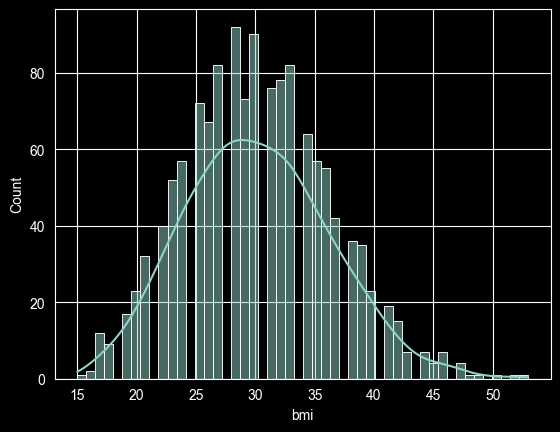

In [41]:
sns.histplot(df_clean['bmi'],kde=True,bins=50)
# sns.countplot(x=df_clean['smoker'])

In [42]:
df_clean['bmi_category']=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['UnderWeight','NormalWeight','OverWeight','Obese'],
    include_lowest=True,
)

In [43]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,OverWeight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,NormalWeight
4,32,0,28,0,0,3866,1,0,0,OverWeight


In [44]:
df_clean=pd.get_dummies(df_clean,columns=['bmi_category'],drop_first=True)

In [45]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_NormalWeight,bmi_category_OverWeight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [46]:
df_clean=df_clean.astype(int)

In [60]:
df_clean
import  scipy.stats as stats

In [48]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_NormalWeight', 'bmi_category_OverWeight',
       'bmi_category_Obese'],
      dtype='str')

In [50]:
from sklearn.preprocessing import StandardScaler

In [51]:
cols=['age','bmi','children']
scale=StandardScaler()
df_clean[cols]=scale.fit_transform(df_clean[cols])

In [52]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_NormalWeight,bmi_category_OverWeight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [55]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_NormalWeight', 'bmi_category_OverWeight',
       'bmi_category_Obese'],
      dtype='str')

In [57]:
print(df_clean.dtypes)

age                          float64
is_female                      int64
bmi                          float64
children                     float64
is_smoker                      int64
charges                        int64
region_northwest               int64
region_southeast               int64
region_southwest               int64
bmi_category_NormalWeight      int64
bmi_category_OverWeight        int64
bmi_category_Obese             int64
dtype: object


In [58]:
col=['age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_NormalWeight', 'bmi_category_OverWeight',
       'bmi_category_Obese']

<Axes: >

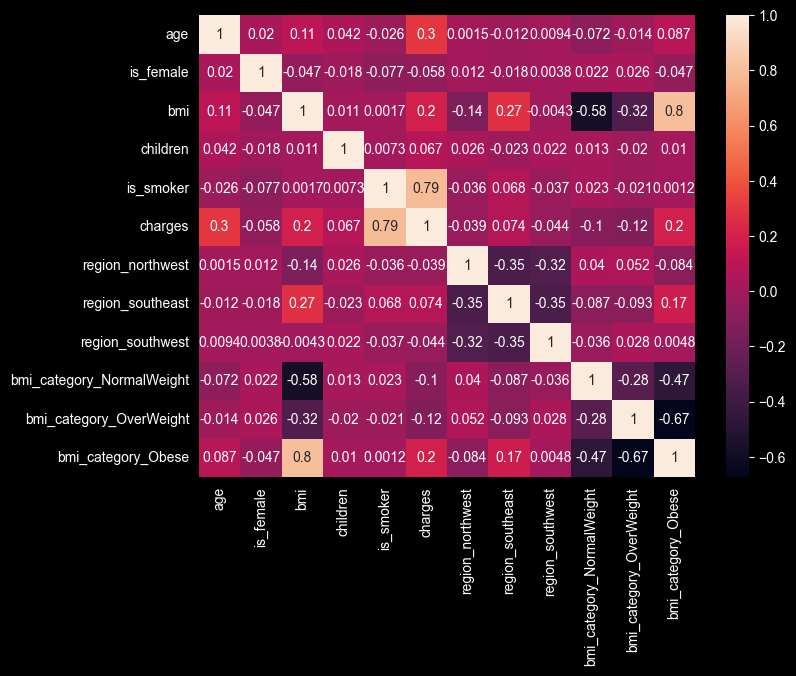

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(),annot=True)

In [61]:
from scipy.stats import pearsonr

In [62]:
correlations={
    features:pearsonr(df_clean[features],df_clean['charges'])[0]
    for features in col
}
correlations_df=pd.DataFrame(list(correlations.items()),columns=['features','Pearson'])
correlations_df.sort_values(by='Pearson',ascending=False,inplace=True)

In [63]:
correlations_df

,features,Pearson
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
2,bmi,0.196236
6,region_southeast,0.073577
3,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
1,is_female,-0.058046
8,bmi_category_NormalWeight,-0.104042


In [64]:
cat_feature=[
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_NormalWeight',
    'bmi_category_OverWeight',
    'bmi_category_Obese',

]

In [67]:
from scipy.stats import chi2_contingency
alpha=0.05
df_clean['charges_bin']=pd.qcut(df_clean['charges'],q=4,labels=False,duplicates='drop')

In [72]:
chi2_result = {}

for col in cat_feature:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])

    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

    decision = "Reject Null (Keep Feature)" if p_val < alpha else "Accept  Null (Drop Feature)"

    chi2_result[col] = {
        'chi2_stat': chi2_stat,
        'p_val': p_val,
        'dof': dof,
        'decision': decision,
    }

In [77]:
chi2_df = pd.DataFrame(chi2_result).T.sort_values(by='p_val')
print(chi2_df)

                            chi2_stat     p_val dof  \
is_smoker                  848.219178       0.0   3   
region_southeast            15.998167  0.001135   3   
is_female                   10.258784   0.01649   3   
bmi_category_Obese           8.515711  0.036473   3   
region_southwest             5.091893  0.165191   3   
bmi_category_OverWeight       4.25149  0.235557   3   
bmi_category_NormalWeight    3.708088   0.29476   3   
region_northwest              1.13424  0.768815   3   

                                              decision  
is_smoker                   Reject Null (Keep Feature)  
region_southeast            Reject Null (Keep Feature)  
is_female                   Reject Null (Keep Feature)  
bmi_category_Obese          Reject Null (Keep Feature)  
region_southwest           Accept  Null (Drop Feature)  
bmi_category_OverWeight    Accept  Null (Drop Feature)  
bmi_category_NormalWeight  Accept  Null (Drop Feature)  
region_northwest           Accept  Null (Drop Fe

In [78]:
final_df = df_clean[
    ['age', 'is_female', 'bmi', 'charges',
     'is_smoker', 'children',
     'bmi_category_Obese', 'region_southeast']
]

In [79]:
final_df

,age,is_female,bmi,charges,is_smoker,children,bmi_category_Obese,region_southeast
0,-1.440418,1,-0.517949,16884,1,-0.909234,0,0
1,-1.511647,0,0.462463,1725,0,-0.079442,1,1
2,-0.799350,0,0.462463,4449,0,1.580143,1,1
3,-0.443201,0,-1.334960,21984,0,-0.909234,0,0
4,-0.514431,0,-0.354547,3866,0,-0.909234,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,10600,0,1.580143,1,0
1334,-1.511647,1,0.135659,2205,0,-0.909234,1,0
1335,-1.511647,1,0.952670,1629,0,-0.909234,1,1
1336,-1.297958,1,-0.844753,2007,0,-0.909234,0,0


In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
model=LinearRegression()

In [86]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
y_pred=model.predict(X_test)

In [88]:
y_pred

array([ 7856.41808069,  5379.07145062, 14613.47489419, 32465.93193508,
        8955.35729283, 13336.43605749, 30199.07309038,  1403.40503994,
       11196.90873514, 10018.65838301, 10818.71629044, 32144.43533014,
       31550.26059902, 16230.55597963, 10285.99989714,  8488.6608457 ,
        5487.64476113, 32465.09672212,  3304.46601962,  3877.00422671,
        4760.01023433, 28796.29743032, 13870.98195763, 29541.88243902,
       31520.15678042,  6344.44675222, 35026.69683204, 37880.73853364,
       12490.06211178, 14238.95332785,  7573.09915473, 13049.08020135,
         516.21534048, 11339.74207305, 37584.28749479, 13356.84393437,
        3706.96614326,  4537.12786929, 31481.80485676,  8009.55465514,
        6075.79442888, 30404.81913857, 35276.56346051, 13099.59189682,
        7977.69705664,  2987.00634487,  5174.11237148,  7620.54073087,
        3522.89053725, 10388.99625751,  7820.00530896, 10505.68054495,
       30331.09138384,  4687.62077185, 11676.0149257 , 11446.77536361,
      

In [89]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [92]:
from sklearn.metrics import r2_score

In [93]:
r2=r2_score(y_test,y_pred)

In [94]:
r2

0.8040712413347118

In [97]:
n=X_test.shape[0]
p=X_test.shape[1]

In [98]:
adjusred_r2=1-((1-r2)*(n-1)/(n-p-1))

In [99]:
adjusred_r2

0.7987962362937232